## For Google Colab

In [ ]:
# For google colab
from google.colab import drive
drive.mount('/content/drive')
import sys
sys.path.append('/content/drive/Othercomputers/My Mac/src/')
colab=True
!pip install mnist1d

Mounted at /content/drive


## Configuration

In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
from pathlib import Path
from tqdm import tqdm
import json
import sys
import os
import pickle
import pandas as pd
if 'colab' not in locals():
  sys.path.insert(0, "../src/")
from Network import *
from plotting import *
from utilsMNIST import *
from utils import *
from mnist1d.data import make_dataset, get_dataset_args, get_templates
from mnist1d.utils import from_pickle, to_pickle, ObjectView, set_seed, plot_signals

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)
model_config = dict(default_model_config)
dt = general_config["dt"]
data_config["final_seq_length"] = int(data_config["duration"]/dt)

seed = 0
os.environ["PYTHONHASHSEED"] = str(seed)
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
torch.backends.cudnn.deterministic = True

n_steps = data_config["final_seq_length"]
answer_steps = int(model_config["answer_period"]/dt)
pad_steps = int(data_config["prepad"]/dt)

error_window = 20
error_steps = -1#6 #number of error_window
max_error_start = n_steps - error_window -1 
min_error_start = n_steps - answer_steps

Skip = True
small_model = False
GLE_like = False

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

save_path = "../Figures/MNIST1DRecord.pkl"

beta = torch.zeros(n_steps).to(device)
beta[-answer_steps:]=1.
beta /= beta.sum()

if small_model: #small model (14k) for notebook demonstration
    train_config["num_epochs"] = 100
    model_config["LP_size"] = [36, 54, 60, 60] # acc 92
    model_config["Ins_size"] = [72]


if Skip: #small skip connection for notebook demonstration
    model_config["LP_size"] = [60, 60, 60, 60, 72]
    model_config["Ins_size"] = [72]
    model_config["num_LP_layers"] = 5
    model_config["num_Ins_layers"] = 1
    model_config['Tau3'] = [1, 8.0]
    model_config['Tau4'] = [2.5, 6.6]
    model_config['skip_connection'] = "One"

#######################
if error_steps != -1:
    model_config['skip_connection'] = "All"
    answer_steps = 180
    model_config['Tau4'] = [80, 120]
    model_config['rho_scale'] = 0.25

if GLE_like: #GLE Compare
    model_config["LP_size"] = [54, 54, 54, 54, 54, 54]
    model_config["num_LP_layers"] = 6
    model_config["num_Ins_layers"] = 0
    model_config['Tau1'] = [1.2, 3.2, 6.2]
    model_config['Tau2'] = [1.1, 3.1, 6.1]
    model_config['Tau3'] = [1.3, 3., 6.]
    model_config['Tau4'] = [1.4, 2.9, 5.9]
    model_config['Tau5'] = [1., 2.8, 5.8]
    model_config['rho_scale'] = 0.5

cpu


## Prepare MNIST-1D

Templates for the MNIST-1D dataset:


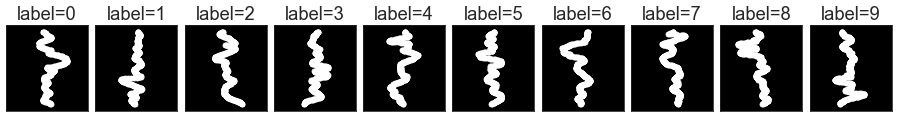

In [3]:
data = make_dataset(ObjectView(data_config))
templates = get_templates()
print("Templates for the MNIST-1D dataset:")
x = templates['x']
t = templates['t']
y = templates['y']
fig = plot_signals(x, t, labels=y, args=ObjectView(data_config),
                   ratio=1.33, dark_mode=True, do_transform=True)

In [4]:
print(data.keys())
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'], dtype=torch.int64)
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'], dtype=torch.int64)
x.shape, y.shape

dict_keys(['x', 'x_test', 'y', 'y_test', 't', 'templates'])


(torch.Size([4000, 360, 1]), torch.Size([4000]))

## Train KP

In [5]:
Method = 'KP'
# init network and optimizer
train_config["update_times"] = 3
if Method=='BPTT':
    model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)
    train_fn = train_batch_BPTT
    factor = 0.75
    adam_beta = (0.9, 0.999)
else:
    if train_config["update_times"]>1:
        update_timing = n_steps-np.linspace(0, n_steps, num=train_config["update_times"], endpoint=False, dtype=np.int16)-1
        train_fn = train_batch_periodic(update_timing = update_timing)
    else:
        train_fn = train_batch_delay
    factor = 0.75
    adam_beta = (0.8, 0.995)
    if Method=='KP':
        model = buildKPNet(model_config, general_config).to(device)
    elif Method in ['GLE','RF/E','LE']:
        model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)
    else:
        raise NotImplementedError

model = torch.compile(model)

if GLE_like:
    model.layers[0].tau = model.layers[3].tau 
    model.layers[0].dt_tau = model.layers[3].dt_tau
    model.layers[0].decay = model.layers[3].decay
    model.layers[0].tau_dt = model.layers[3].tau_dt
    if Method == 'KP':
        model.layers[0].tau_unique = model.layers[3].tau_unique
        model.layers[0].dt_tau_uniq = model.layers[3].dt_tau_uniq
        model.layers[0].decay_uniq = model.layers[3].decay_uniq
        model.layers[0].repeat_tau = model.layers[3].repeat_tau
        model.layers[0].n_tau = model.layers[3].n_tau
    adam_beta = (0.9, 0.999)
    factor = 0.75
    train_config["learning_rate"] = 1e-2

if Method=="GLE":
    for l in model.layers[:4]:
        #l.tau_dt = torch.clamp(l.tau_dt, 0, 5)
        l.tau_dt /= 3

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
    betas=adam_beta,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=factor,
    patience=2
)

kernel_record_pre = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

best_test_acc = 0.

rho bar
A skip connection activated


In [6]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        if error_steps==-1:
            beta_random = beta
        else:
            beta_random = torch.zeros(n_steps).to(device)
            select_steps = np.random.choice(max_error_start-min_error_start, error_steps, replace=False) + min_error_start
            for error_start in select_steps:
                beta_random[error_start: error_start+error_window] = 1.
            beta_random /= beta_random.sum()
        total_error = train_fn(model, optimizer, x[idx].to(device),
                                        y[idx].to(device), answer_steps, pad_steps, beta_random)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step(test_loss)
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

Training started...


 42%|███████████████████████████████████▎                                               | 17/40 [00:42<00:57,  2.49s/it]


KeyboardInterrupt: 

In [26]:
for l in model.layers:
    print(l.W_in.grad.data.norm(2))

tensor(0.0018)
tensor(0.0050)
tensor(0.0045)
tensor(0.0051)
tensor(0.0075)
tensor(0.0188)


### Save record to pickle

In [13]:
save_dict = {'acc':np.array(acc_record), 'loss':np.array(loss_record), 'seed':seed, 'error_signal':(error_window, error_steps)}
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)
group = 'Small' if small_model else 'Large'
if Skip:
    group = 'Skip'
#All_record[group][Method].append(save_dict)
All_record["Error_Occ"] = {}
All_record["Error_Occ"][group]=[save_dict]

with open(save_path, 'wb') as handle:
    pickle.dump(All_record, handle, protocol=pickle.HIGHEST_PROTOCOL)

All_record

{'Small': {'n_param': 14080,
  'KP': [{'acc': array([35.8, 34.6, 20.1, 41.8, 60.3, 44. , 50. , 59.9, 57.2, 50.8, 58.3,
           60.8, 59.8, 58. , 61.1, 61.5, 76.8, 71. , 56.4, 66.4, 74.1, 75.2,
           68.6, 81.3, 79.6, 80.7, 76.8, 83.9, 85.2, 71. , 67.3, 87. , 77.6,
           77.8, 81.2, 85. , 83.8, 86. , 88.5, 85.5, 86.5, 86.7, 79.1, 83.9,
           83.2, 84.5, 89.6, 88.4, 86. , 86.1, 88.2, 89.2, 87.2, 90.6, 90.1,
           90.3, 86.1, 89.2, 92.1, 90.9, 89.8, 91.1, 91.4, 88.7, 92.6, 92.8,
           87.3, 91.3, 92.2, 93.1, 92.3, 92.8, 91.2, 91.1, 93.9, 93.5, 92.4,
           92.5, 92.6, 93.3, 92.2, 93.4, 92.6, 90.7, 93.6, 92.6, 94.7, 93.1,
           94.7, 93.1, 94.5, 93.8, 93.9, 93.3, 93.2, 94. , 93. , 94.2, 94.8,
           94.5, 93.9, 93.7, 94.1, 94.1, 94.1, 93.3, 94.5, 95.6, 95.1, 94.1,
           94.6]),
    'loss': array([0.2146, 0.2113, 0.2104, 0.2047, 0.2011, 0.1985, 0.1966, 0.1934,
           0.1935, 0.1946, 0.1901, 0.1876, 0.1872, 0.1879, 0.1831, 0.1871,
           

## Plot Learning Curve

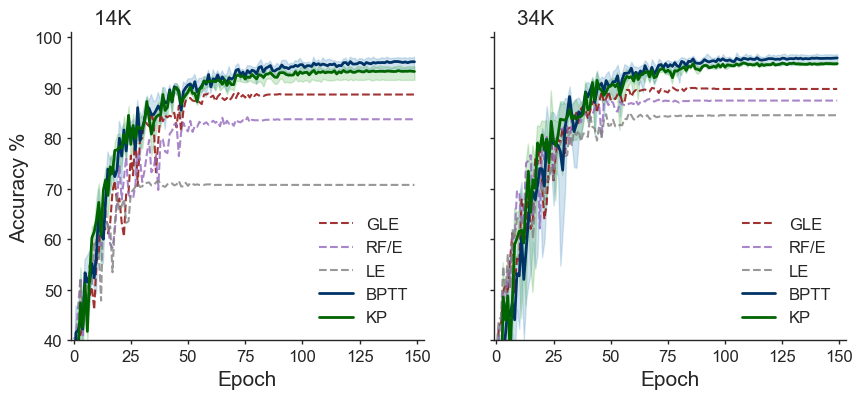

In [3]:
plot_config = {'Large': {'KP':[darkgreen, 'KP'],
                         'BPTT': [darkblue, 'BPTT'],
                         'GLE': [darkred, 'GLE'],
                         'RF/E': [purple, 'RF/E'],
                         'LE': [gray, 'LE'],
                         },
               'Small': {'KP': [green, 'KP'],
                         'BPTT': [blue, 'BPTT'],
                         'GLE': [darkred, 'GLE'],
                         'RF/E': [purple, 'RF/E'],
                         'LE': [gray, 'LE'],
                         },
               'Skip': {'KP': [darkgreen, 'KP'],
                        'BPTT': [darkblue, 'BPTT'],
                       }
               }

with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)

df = pd.read_csv("../Figures/MNIST1D_KP_BPTT.csv", index_col='Step')
epochs = np.arange(150)
### Large and Small model ###
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for i, group in enumerate(['Small', 'Large']):
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].tick_params(axis='both', which='major', labelsize=12)
    
    for method in All_record[group].keys():
        record = All_record[group][method]
        if method in ['n_param', 'KP', 'BPTT'] or len(record)==0:
            continue
        color, label = plot_config[group][method]
        for re in record:
            if len(re['acc'])<150:
                re['acc'] = np.pad(re['acc'], (0, 150-len(re['acc'])), mode = 'edge')
                re['loss'] = np.pad(re['loss'], (0, 150-len(re['loss'])), mode = 'edge')
            axs[i].plot(re['acc'], label=label, color=color, linewidth=1.5, alpha=0.8, linestyle='--')

axs[0].plot(df["Group: small_BPTT - test_acc"], label="BPTT", color=darkblue, linewidth=2)
axs[0].fill_between(epochs, df["Group: small_BPTT - test_acc__MIN"], df["Group: small_BPTT - test_acc__MAX"], alpha=0.2, color=blue)
axs[1].plot(df["Group: Large_BPTT - test_acc"], label="BPTT", color=darkblue, linewidth=2)
axs[1].fill_between(epochs, df["Group: Large_BPTT - test_acc__MIN"], df["Group: Large_BPTT - test_acc__MAX"], alpha=0.2, color=blue)

axs[0].plot(df["Group: Small - test_acc"], label="KP", color=darkgreen, linewidth=2)
axs[0].fill_between(epochs, df["Group: Small - test_acc__MIN"], df["Group: Small - test_acc__MAX"], alpha=0.2, color=green)
axs[1].plot(df["Group: Large - test_acc"], label="KP", color=darkgreen, linewidth=2)
axs[1].fill_between(epochs, df["Group: Large - test_acc__MIN"], df["Group: Large - test_acc__MAX"], alpha=0.2, color=green)

axs[0].set_ylim(40, 101)
axs[0].set_xlim(-1, 153)
axs[1].set_xlim(-1, 153)
axs[0].set_xlabel('Epoch', fontsize = 15)
axs[1].set_xlabel('Epoch', fontsize = 15)
axs[0].set_ylabel('Accuracy %', fontsize = 15)
#axs[1].set_ylabel('Accuracy %', fontsize = 15)
axs[0].set_title('    14K', loc='left', fontsize = 15)
axs[1].set_title('    34K', loc='left', fontsize = 15)

axs[0].legend(loc='lower right', fontsize = 12)
axs[1].legend(loc='lower right', fontsize = 12)

plt.savefig('../Figures/MNIST1D_S-L.png')
plt.show()

In [4]:
df2 = pd.read_csv("../Figures/MNIST1D_SKIP.csv")
result = {}

# extract sorted seeds
seeds = np.sort(df2['general_config.seed'].unique())
result['seed'] = seeds

methods = ['BPTT', 'KP']
ins_sizes = ['[72]', '[120]']

for method in methods:
    for ins in ins_sizes:
        for skip in [True, False]:
            if (ins=='[120]' and skip):
                continue
            sub = df2[
                (df2['train_config.method'] == method) &
                (df2['model_config.Ins_size'] == ins) &
                (df2['model_config.skip_connection'] == skip)
            ]
            
            # align order with seeds
            sub = sub.set_index('general_config.seed').loc[seeds]
            
            key = f"{method}_{'skip' if skip else 'noskip'}_{ins}"

            result[key] = (
                sub['Best Test Acc']
                .reindex(seeds)      # safe alignment
                .to_numpy()
            )

print(result)

{'seed': array([   0,   42,  428,  781, 3407]), 'BPTT_skip_[72]': array([96.8, 95.9, 96. , 96.3, 95.2]), 'BPTT_noskip_[72]': array([94.2, 95.5, 96.1, 95.6, 96.1]), 'BPTT_noskip_[120]': array([95.6, 96.8, 95.1, 96.2, 97. ]), 'KP_skip_[72]': array([95.8, 95.9, 96.1, 96. , 95.5]), 'KP_noskip_[72]': array([91.9, 94.5, 93.7, 93.9, 94.6]), 'KP_noskip_[120]': array([95. , 95. , 95.3, 95.1, 95.3])}


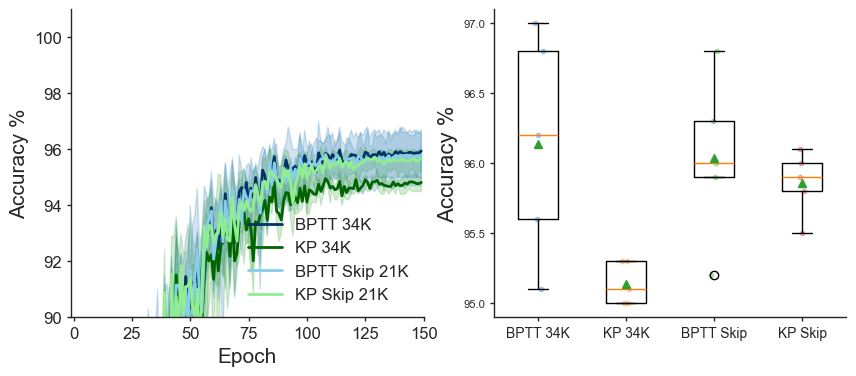

In [16]:
### Large and Skip model ###
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

####ax0#####
axs[0].plot(df["Group: Large_BPTT - test_acc"], label="BPTT 34K", color=darkblue, linewidth=2)
axs[0].fill_between(epochs, df["Group: Large_BPTT - test_acc__MIN"], df["Group: Large_BPTT - test_acc__MAX"],
                    alpha=0.2, color=blue)
axs[0].plot(df["Group: Large - test_acc"], label="KP 34K", color=darkgreen, linewidth=2)
axs[0].fill_between(epochs, df["Group: Large - test_acc__MIN"], df["Group: Large - test_acc__MAX"],
                    alpha=0.2, color=green)

axs[0].plot(df["Group: skip_BPTT - test_acc"], label="BPTT Skip 21K", color=lightblue, linewidth=2)
axs[0].fill_between(epochs, df["Group: skip_BPTT - test_acc__MIN"], df["Group: skip_BPTT - test_acc__MAX"],
                    alpha=0.2, color=blue)
axs[0].plot(df["Group: skip - test_acc"], label="KP Skip 21K", color=lightgreen, linewidth=2)
axs[0].fill_between(epochs, df["Group: skip - test_acc__MIN"], df["Group: skip - test_acc__MAX"],
                    alpha=0.2, color=green)
axs[0].set_ylim(90, 101)
axs[0].set_xlim(-1, 150)
axs[0].set_xlabel('Epoch', fontsize = 15)
axs[0].set_ylabel('Accuracy %', fontsize = 15)
axs[0].spines['top'].set_visible(False)
axs[0].spines['right'].set_visible(False)
axs[0].tick_params(axis='both', which='major', labelsize=12)
axs[0].legend(loc='lower right', fontsize = 12)

####ax1#####
data = [result['BPTT_noskip_[120]'], result['KP_noskip_[120]'], result['BPTT_skip_[72]'], result['KP_skip_[72]']]
#axs[1].violinplot(data, positions=[0,1,2,3], showmeans=True)
axs[1].boxplot(data, positions=[0,1,2,3], showmeans=True)
axs[1].set_xticks([0,1,2,3], ['BPTT 34K', 'KP 34K', 'BPTT Skip', 'KP Skip'], fontsize=10)
axs[1].set_ylabel("Accuracy %", fontsize=16)
axs[1].set_yticks([95, 95.5, 96, 96.5, 97])
axs[1].spines['top'].set_visible(False)
axs[1].spines['right'].set_visible(False)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    axs[1].scatter(x, d, alpha=0.3, s=10)

plt.savefig('../Figures/MNIST1D_Skip.png')
plt.show()

In [ ]:
for l in model.layers[:2]:
    print(l.TauDE, l.decay_de)
    print(l.elig.shape, torch.abs(l.elig).mean())
    print(torch.abs(l.W_in).mean(), torch.abs(l.bias).mean())
    print()

In [ ]:
#TEST
acc, loss = test(model, x_test.to(device), y_test.to(device), 1.4*answer_period)
print('Test Accuracy: ', acc, "Test Loss", loss)

In [ ]:
kernel_record_post = extract_kernel(
    model,
    n_steps=int(1.5*data_config["final_seq_length"]),
    layer_idx=model_config["num_LP_layers"]
)

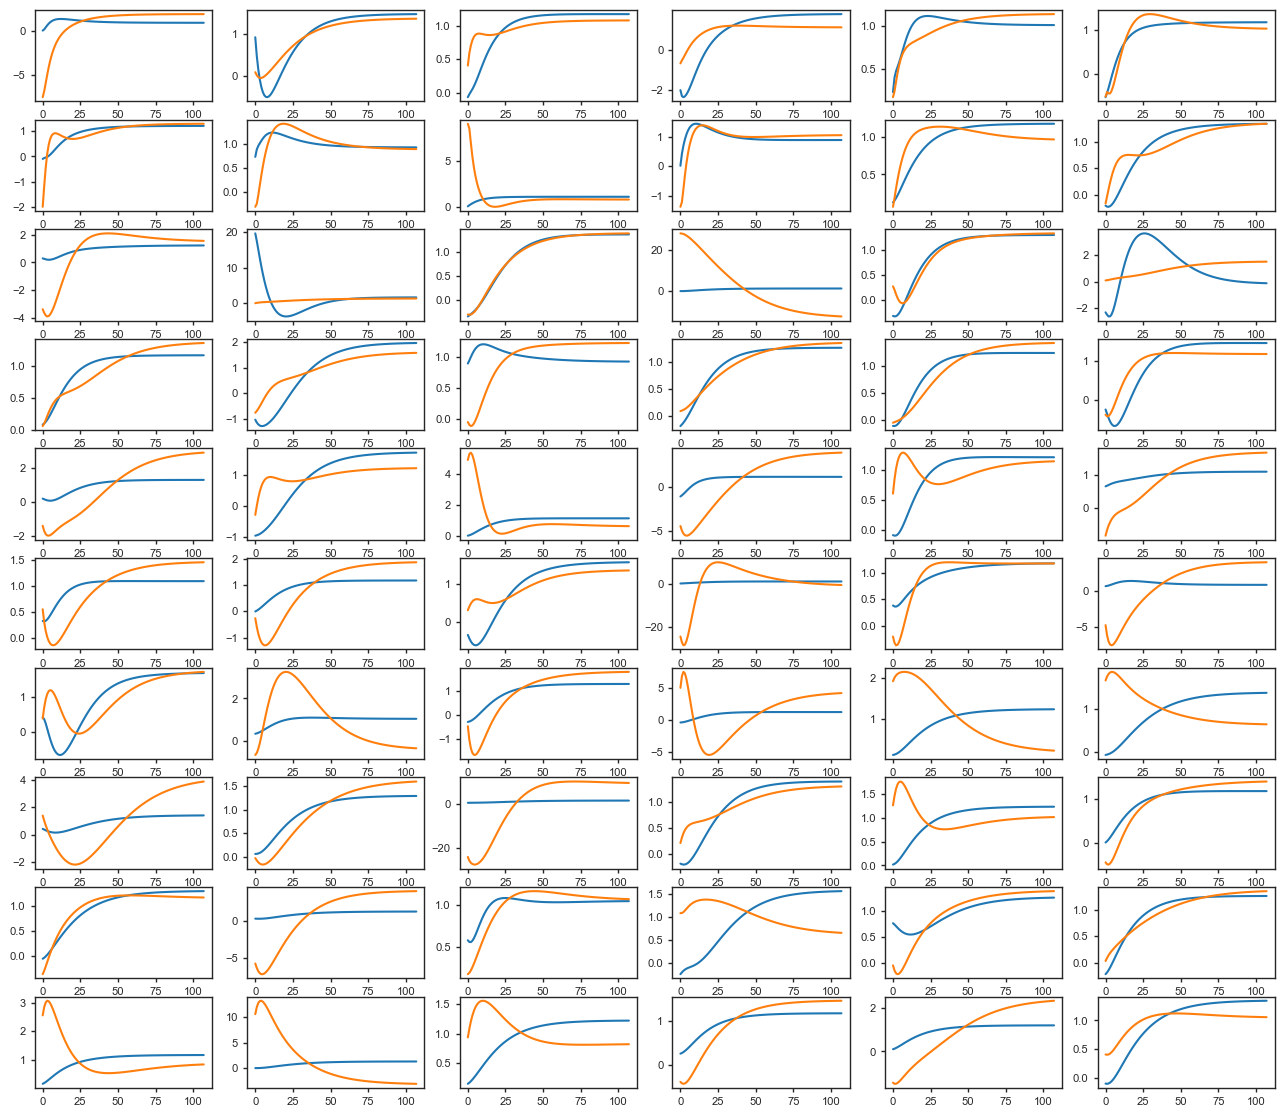

In [ ]:
kernel_record_pre_norm = kernel_record_pre / kernel_record_pre.mean(axis=1)[:, None]
kernel_record_post_norm = kernel_record_post / kernel_record_post.mean(axis=1)[:, None]
fig, axs = plt.subplots(10, 6, figsize=(16, 14))
for i, ax in enumerate(axs.ravel()):
    ax.plot(kernel_record_pre_norm[i])
    ax.plot(kernel_record_post_norm[i])

## Evaluation

In [14]:
Saved_model = Path("..") / "saved_models" / "MNIST1D95.2"
with open(Saved_model / "general_config.json") as f:
    general_config = json.load(f)
with open(Saved_model / "model_config.json") as f:
    model_config = json.load(f)
with open(Saved_model / "data_config.json") as f:
    data_config = json.load(f)

general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
data = make_dataset(ObjectView(data_config))
x, y = torch.tensor(data['x'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y'], dtype=torch.int64)
x_test, y_test = torch.tensor(data['x_test'],dtype=torch.float32).unsqueeze(-1), torch.tensor(data['y_test'], dtype=torch.int64)

dt = general_config["dt"]
data_config["final_seq_length"] = int(data_config["duration"]/dt)

n_steps = data_config["final_seq_length"]
answer_steps = int(model_config["answer_period"]/dt)
pad_steps = int(data_config["prepad"]/dt/2)
model_config["rho_scale"] = 0.6

model = buildKPNet(model_config, general_config).to(device)
state_dict = torch.load(Saved_model / "best_model_state.pt", map_location=device)
print(model.load_state_dict(state_dict))
print(model_config)

C:\Users\Bingkun LIU\AppData\Local\Temp\ipykernel_31940\3904141388.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(Saved_model / "best_model_sta

RuntimeError: Error(s) in loading state_dict for DEFwdNetwork:
	Missing key(s) in state_dict: "layers.0.tau_unique", "layers.0.dt_tau_uniq", "layers.0.decay_uniq", "layers.0.repeat_tau", "layers.1.repeat_tau", "layers.2.repeat_tau", "layers.3.repeat_tau". 

In [16]:
W = state_dict['layers.0.W_in'].squeeze()
for i in np.arange(10):
    print(torch.sort(W[i*6: i*6+6])[0])

tensor([-2.7663, -0.1169, -0.0715,  0.1248,  1.6720,  2.1343], device='cuda:0')
tensor([-3.3173, -1.3924, -0.2785, -0.1088,  1.1048,  1.1537], device='cuda:0')
tensor([-0.1274,  0.1104,  0.3072,  0.7757,  1.2825,  1.5832], device='cuda:0')
tensor([-2.4090, -1.0736, -0.6458, -0.1624,  0.0671,  0.1192], device='cuda:0')
tensor([-2.8517, -0.0927, -0.0382,  0.1000,  0.3959,  0.6966], device='cuda:0')
tensor([-0.1148, -0.0709,  0.0029,  0.0328,  0.0652,  0.1225], device='cuda:0')
tensor([-0.2970, -0.0466, -0.0405,  0.0026,  0.1004,  0.3007], device='cuda:0')
tensor([-6.6565e-02,  5.3552e-04,  4.4162e-02,  6.6170e-02,  7.7958e-01,
         1.2237e+00], device='cuda:0')
tensor([-2.3673, -1.8933, -0.2230, -0.0837, -0.0367,  1.5093], device='cuda:0')
tensor([-0.3171, -0.2684, -0.2162,  0.3044,  0.3156,  1.9944], device='cuda:0')


In [31]:
state_dict['layers.0.tau']

tensor([ 1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.0000,  1.2915,  1.2915,
         1.2915,  1.2915,  1.2915,  1.2915,  1.6681,  1.6681,  1.6681,  1.6681,
         1.6681,  1.6681,  2.1544,  2.1544,  2.1544,  2.1544,  2.1544,  2.1544,
         2.7826,  2.7826,  2.7826,  2.7826,  2.7826,  2.7826,  3.5938,  3.5938,
         3.5938,  3.5938,  3.5938,  3.5938,  4.6416,  4.6416,  4.6416,  4.6416,
         4.6416,  4.6416,  5.9948,  5.9948,  5.9948,  5.9948,  5.9948,  5.9948,
         7.7426,  7.7426,  7.7426,  7.7426,  7.7426,  7.7426, 10.0000, 10.0000,
        10.0000, 10.0000, 10.0000, 10.0000], device='cuda:0')

In [7]:
general_config

{'device': 'cpu',
 'dt': 1.0,
 'seed': 89,
 'short_training_run': False,
 'visual_kernel': False}

In [8]:
test_acc, test_acc_r, test_acc_m = test_mul(model, x_test.to(device), y_test.to(device), answer_steps, pad_steps, beta)

In [9]:
print(test_acc, test_acc_r, test_acc_m)

95.6 94.9 81.1


## Gradient similarity

### With layers

In [18]:
model_config["LP_size"] = [60, 60, 60, 60, 60, 60, 60]
model_config["num_LP_layers"] = 7
model_config["num_Ins_layers"] = 0
model_config['Tau1'] = [2.2, 3.2, 5.2]
model_config['Tau2'] = [2.1, 3.1, 5.1]
model_config['Tau3'] = [2., 3., 5.]
model_config['Tau4'] = [1.9, 2.9, 4.9]
model_config['Tau5'] = [1.8, 2.8, 4.8]
model_config['Tau6'] = [1.7, 2.7, 4.7]
model_config["version"] = 0

nLP = model_config['num_LP_layers']
CosSim = torch.nn.CosineSimilarity(dim=-1, eps=1e-6)
num_repeat = 20
Rho_scales = [0.2, 0.6, 1.]
CosSimW, CosSimW2 = [], []

for rho_scale in Rho_scales:
    model_config["rho_scale"] = rho_scale
    CosSimW_record = [[] for _ in range(nLP)]
    CosSimW2_record = [[] for _ in range(nLP)]
    for _ in range(num_repeat):
        model = buildKPNet(model_config, general_config)
        ##### assigned tau to LP rho'###
        # tau = 14
        for l in model.layers[:nLP]:
            l.dt_tau_rho = l.dt_tau#1 / tau
            l.decay_rho = 1 - l.dt_tau_rho
        #     tau -= 2
        ##################################
        idx = (np.random.permutation(4000).reshape(-1, train_config["batch_size"]))[0]
        sample_batch_x = x[idx]
        one_hot_label = one_hot_label = F.one_hot(y[idx], num_classes=10)
        model.reset()
        GradW_all_time = [[] for _ in range(nLP)]
        GradW2_all_time = [[] for _ in range(nLP)]
        total_loss = 0.
        for t in range(n_steps):
            r_out,_ = model.step(sample_batch_x[:, t])
            if n_steps-t <= answer_steps:
                p = torch.softmax(r_out, dim=1)
                loss_t = -(one_hot_label * torch.log(p)).mean(dim=0).sum()*beta[t]
                total_loss += loss_t
                if beta[t] != 0:
                    error = (one_hot_label - p)*beta[t]
                    model.prop(error=error)
                    for i in reversed(range(nLP)):
                        (dW, dW2), (db, db2) = model.layers[i].comp_grad()
                        GradW_all_time[i].append(dW.detach())
                        GradW2_all_time[i].append(dW2.detach())
                else:
                    model.prop(learn=False)
            else:
                model.prop(learn=False)
                
        model.zero_grad()       
        total_loss.backward()
        for i in range(nLP):
            GradW_all_time[i] = torch.stack(GradW_all_time[i])
            GradW2_all_time[i] = torch.stack(GradW2_all_time[i])
            if i==0:
                cos_sim = CosSim(model.layers[i].W_in.grad.T, GradW_all_time[i].sum(dim=0).T).detach()
                cos_sim2 = CosSim(model.layers[i].W_in.grad.T, GradW2_all_time[i].sum(dim=0).T).detach()
            else:
                cos_sim = CosSim(model.layers[i].W_in.grad, GradW_all_time[i].sum(dim=0)).detach()
                cos_sim2 = CosSim(model.layers[i].W_in.grad, GradW2_all_time[i].sum(dim=0)).detach()
            CosSimW_record[i].append(cos_sim)
            CosSimW2_record[i].append(cos_sim2)
    
    for i in range(nLP):
        CosSimW_record[i] = torch.hstack(CosSimW_record[i]).numpy()
        CosSimW2_record[i] = torch.hstack(CosSimW2_record[i]).numpy()
        #print(CosSimW_record[i].shape, CosSimW_record[i].mean())
    CosSimW.append(CosSimW_record)
    CosSimW2.append(CosSimW2_record)

In [53]:
def plotCosDis(cos_dissim, rho_scl, v, num, ax):
    means, low, high = [], [], []
    
    for i in range(num):
        d = cos_dissim[i].flatten()
    
        med = np.median(d)
        p25 = np.percentile(d, 25)
        p75 = np.percentile(d, 75)
    
        means.append(med)
        low.append(med - p25)
        high.append(p75 - med)

    x = np.arange(num)-0.3 if v==1 else np.arange(num)+0.3
    x = np.arange(num)-0.15 if v==1 else np.arange(num)+0.15
    x += rho_scl*0.25 - 0.1
    color = blue if v==1 else red
    label = r"$\rho'$" if v==1 else r"$\bar{\rho'}$"
    label += r', $\alpha=$%.1f'%rho_scl
    ax.errorbar(
        x,
        means,
        yerr=[low, high],
        fmt='v',
        capsize=4,
        label = label,
        color=color,
        alpha = rho_scl,
        ls='--', 
        capthick=1, 
        ecolor='black',
    )

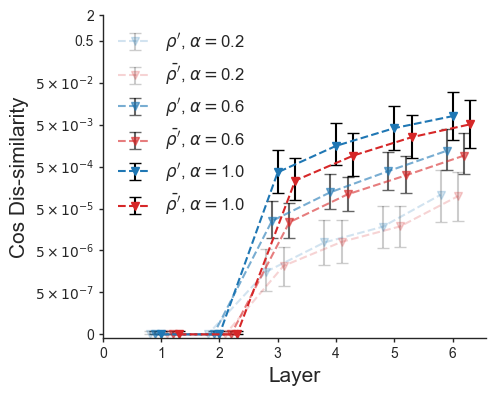

In [54]:
fig, ax = plt.subplots(1, figsize=(5, 4))

for i, rho_scale in enumerate(Rho_scales):
    CosDisSimW, CosDisSimW2 = [], []
    for j in range(nLP-1):
        CosDisSimW.append(np.clip(1-CosSimW[i][nLP-j-1], 5e-8, 2))
        CosDisSimW2.append(np.clip(1-CosSimW2[i][nLP-j-1], 5e-8, 2))
    plotCosDis(CosDisSimW, rho_scale, v=1, num=nLP-1, ax=ax)
    plotCosDis(CosDisSimW2, rho_scale, v=2, num=nLP-1, ax=ax)

ax.set_yscale("log")
ax.set_ylim(4e-8, 1)
ax.set_ylabel("Cos Dis-similarity", fontsize=15)
ax.set_xlabel("Layer", fontsize=15)
ax.set_xlabel("Layer", fontsize=15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xticks(np.arange(nLP)-1, np.arange(nLP))
ax.tick_params(axis='both', which='major', labelsize=10)
ax.set_yticks([5e-8, 5e-7, 5e-6, 5e-5, 5e-4, 5e-3, 5e-2, 5e-1, 2], 
                  [0, r"$5\times 10^{-7}$", r"$5\times 10^{-6}$", r"$5\times 10^{-5}$", 
                   r"$5\times 10^{-4}$", r"$5\times 10^{-3}$", r"$5\times 10^{-2}$",  0.5, 2])
ax.legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradCosSimLayer.png')
plt.show()

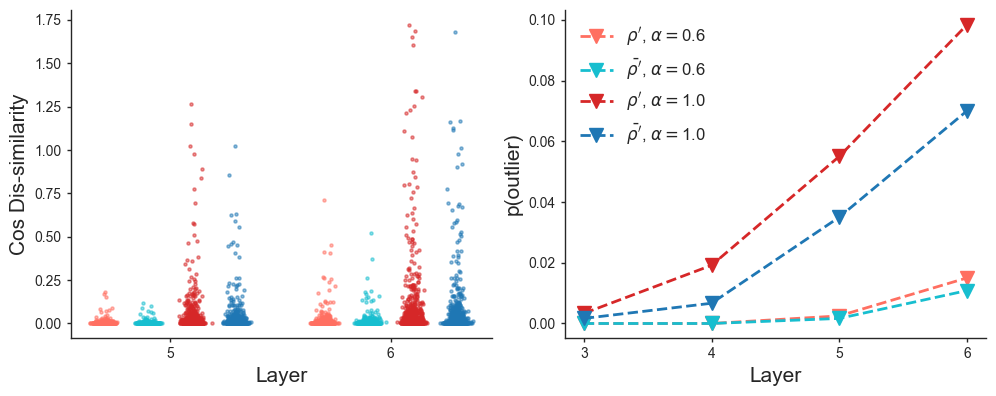

In [36]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
start_l = 4
for i, rho_scale in enumerate(Rho_scales):
    CosDisSimW, CosDisSimW2 = [], []
    OL1, OL2 = [], []
    if i == 0:
        continue
    for j in range(nLP-1):
        CosDisSimW.append(np.clip(1-CosSimW[i][nLP-j-1], 5e-8, 2))
        CosDisSimW2.append(np.clip(1-CosSimW2[i][nLP-j-1], 5e-8, 2))
        num_outlier = (CosDisSimW[-1] > 0.1).sum()
        num_outlier2 = (CosDisSimW2[-1] > 0.1).sum()
        OL1.append(num_outlier/len(CosDisSimW[-1]))
        OL2.append(num_outlier2/len(CosDisSimW[-1]))
    clr1 = pink if i==1 else red
    clr2 = teal if i==1 else blue
    axs[1].plot(OL1[2:], color = clr1, marker='v', markersize=10, linestyle='--', linewidth=2, label=r"$\rho'$, $\alpha=$%.1f"%rho_scale)
    axs[1].plot(OL2[2:], color = clr2, marker='v', markersize=10, linestyle='--', linewidth=2, label=r"$\bar{\rho'}$, $\alpha=$%.1f"%rho_scale)
    x1 = np.arange(nLP-start_l-1)+0.2*(2*i-3)-0.1
    x2 = np.arange(nLP-start_l-1)+0.2*(2*i-3)+0.1
    #axs[0].violinplot(CosDisSimW[start_l:], positions=x1)
    #axs[0].violinplot(CosDisSimW2[start_l:], positions=x2)
    for j, d in enumerate(CosDisSimW[start_l:]):
        x_scat = np.random.normal(x1[j], 0.02, size=len(d))  # small horizontal jitter
        axs[0].scatter(x_scat, d, alpha=0.5, s=5, color=clr1)
    for j, d in enumerate(CosDisSimW2[start_l:]):
        x_scat = np.random.normal(x2[j], 0.02, size=len(d))  # small horizontal jitter
        axs[0].scatter(x_scat, d, alpha=0.5, s=5, color=clr2)

axs[0].set_xticks(np.arange(nLP-start_l-1), np.arange(nLP-start_l-1)+start_l+1)
axs[1].set_xticks(np.arange(nLP-3), np.arange(nLP-3)+3)
for i in range(2):
    axs[i].set_xlabel("Layer", fontsize=15)
    axs[i].set_xlabel("Layer", fontsize=15)
    axs[i].spines['top'].set_visible(False)
    axs[i].spines['right'].set_visible(False)
    axs[i].tick_params(axis='both', which='major', labelsize=10)
axs[0].set_ylabel("Cos Dis-similarity", fontsize=15)
axs[1].set_ylabel("p(outlier)", fontsize=15)

axs[1].legend(fontsize=12)
plt.tight_layout()
plt.savefig('../Figures/GradOutlier.png')
plt.show()

### With tau

In [7]:
model_config["LP_size"] = [60, 60, 60, 60]
model_config["num_LP_layers"] = 4
model_config["num_Ins_layers"] = 0
model_config["version"] = 0
Rho_scales = [0.2, 0.6, 1.]
Tau3 = np.array([2.5])
CosDisSimW, CosDisSimW2 = [[], [], []], [[], [], []]

nLP = model_config['num_LP_layers']
CosSim = torch.nn.CosineSimilarity(dim=-1, eps=1e-6)

CosSimW_record = {}
CosSimW2_record = {}
num_repeat = 20
num_tau = 9

for _ in range(num_tau):
    model_config['Tau3'] = Tau3
    for idx_rho, rho_scale in enumerate(Rho_scales):
        CosSimW = []
        CosSimW2 = []
        model_config["rho_scale"] = rho_scale
        for _ in range(num_repeat):
            model = buildKPNet(model_config, general_config)
            for l in model.layers[:nLP]:
                l.dt_tau_rho = l.dt_tau#1 / tau
                l.decay_rho = 1 - l.dt_tau_rho
            idx = (np.random.permutation(4000).reshape(-1, train_config["batch_size"]))[0]
            sample_batch_x = x[idx]
            one_hot_label = one_hot_label = F.one_hot(y[idx], num_classes=10)
            model.reset()
            GradW_all_time = []
            GradW2_all_time = []
            total_loss = 0.
            for t in range(n_steps):
                r_out,_ = model.step(sample_batch_x[:, t])
                if n_steps-t <= answer_steps:
                    p = torch.softmax(r_out, dim=1)
                    loss_t = -(one_hot_label * torch.log(p)).mean(dim=0).sum()*beta[t]
                    total_loss += loss_t
                    if beta[t] != 0:
                        error = (one_hot_label - p)*beta[t]
                        model.prop(error=error)
                        for i in reversed(range(1, nLP)):
                            (dW, dW2), (db, db2) = model.layers[i].comp_grad()
                        GradW_all_time.append(dW.detach())
                        GradW2_all_time.append(dW2.detach())
                    else:
                        model.prop(learn=False)
                    
                else:
                    model.prop(learn=False)
                    
            model.zero_grad()       
            total_loss.backward()
            GradW_all_time = torch.stack(GradW_all_time)
            GradW2_all_time = torch.stack(GradW2_all_time)
            cos_sim = CosSim(model.layers[1].W_in.grad, GradW_all_time.sum(dim=0)).detach()
            cos_sim2 = CosSim(model.layers[1].W_in.grad, GradW2_all_time.sum(dim=0)).detach()
            CosSimW.append(cos_sim)
            CosSimW2.append(cos_sim2)
        
        CosSimW_record[Tau3[0]] = torch.hstack(CosSimW).numpy()
        CosSimW2_record[Tau3[0]] = torch.hstack(CosSimW2).numpy()
        CosDisSimW[idx_rho].append(np.clip(1-CosSimW_record[Tau3[0]], 5e-8, 2))
        CosDisSimW2[idx_rho].append(np.clip(1-CosSimW2_record[Tau3[0]], 5e-8, 2))
    #print(Tau3[0], CosSimW_record[Tau3[0]].mean())
    Tau3 *= 2

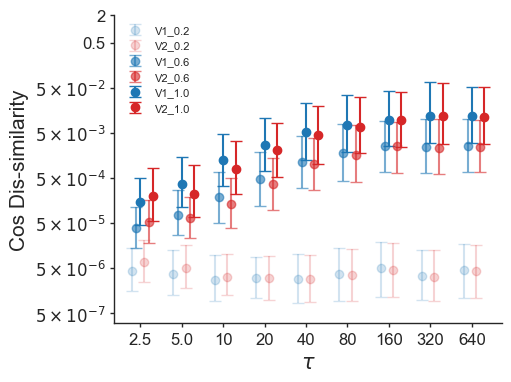

In [17]:
fig, ax = plt.subplots(1, figsize=(5, 4))


xticks = []
for tau in CosSimW_record.keys():
    if tau > 5:
        xticks.append(int(tau))
    else:
        xticks.append(tau)

for i, rho_scale in enumerate(Rho_scales):
    plotCosDis(CosDisSimW[i], rho_scale, v=1, num=num_tau, ax=ax)
    plotCosDis(CosDisSimW2[i], rho_scale, v=2, num=num_tau, ax=ax)

ax.set_yscale("log")
ax.set_ylim(3e-7, 1)
ax.set_ylabel("Cos Dis-similarity", fontsize=15)
ax.set_xlabel(r"$\tau$", fontsize=15)
ax.set_yticks([5e-7, 5e-6, 5e-5, 5e-4, 5e-3, 5e-2, 5e-1, 2], 
                  [r"$5\times 10^{-7}$", r"$5\times 10^{-6}$", r"$5\times 10^{-5}$", 
                   r"$5\times 10^{-4}$", r"$5\times 10^{-3}$", r"$5\times 10^{-2}$",  0.5, 2])
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xticks(np.arange(num_tau), xticks)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend()
plt.tight_layout()
plt.savefig('../Figures/GradCosSimTau.png')
plt.show()

In [83]:
CosDisSimW[0][0]

array([4.0531158e-06, 1.1384487e-05, 4.8822165e-04, ..., 9.0003014e-06,
       8.3446503e-07, 3.0994415e-06], shape=(1200,), dtype=float32)

### With rho scale

## Train BPTT

In [16]:
Method = 'BPTT'
train_fn = train_batch_BPTT
model_config["upsample"] = False
model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=train_config["learning_rate"],
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

best_test_acc = 0.

In [17]:
num_epochs = 100
#acc_record, loss_record = [], []
for epoch in range(num_epochs):
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    Cum_loss = 0.
    for idx in pbar:
        sample = x[idx].to(model.device)
        one_hot_label = F.one_hot(y[idx], num_classes=10).type(torch.FloatTensor).to(model.device)
        total_loss = train_fn(model, optimizer, sample, one_hot_label, 
                                       answer_steps, pad_steps, beta)
        Cum_loss += total_loss

    Cum_loss /= permu.shape[0]
    
    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                                answer_steps, pad_steps, beta)
    scheduler.step(test_loss)
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_loss:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

print('finished')

100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:32<00:00,  1.23it/s]


Epoch: 1, Train Loss: 0.2287,Test Loss: 0.2135,Test Acc: 26.3,Best Acc: 26.3,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:31<00:00,  1.27it/s]


Epoch: 2, Train Loss: 0.2213,Test Loss: 0.2065,Test Acc: 39.1,Best Acc: 39.1,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:31<00:00,  1.28it/s]


...

Epoch: 96, Train Loss: 0.1880,Test Loss: 0.1511,Test Acc: 93.1,Best Acc: 93.4,


100%|██████████████████████████████████████████████████████████████████████████████████| 40/40 [00:31<00:00,  1.27it/s]


Epoch: 97, Train Loss: 0.1880,Test Loss: 0.1511,Test Acc: 93.3,Best Acc: 93.4,


 20%|████████████████▌                                                                  | 8/40 [00:07<00:28,  1.10it/s]


KeyboardInterrupt: 

## Check GLE

In [9]:
Method = 'GLE' #KP, BPTT, GLE, RF/E, LE
model = buildNetCompare(model_config, general_config, neurontype=Method).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=5e-3,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

train_fn = train_batch_delay
best_test_acc = 0.

if Method=="GLE":
    for l in model.layers[:4]:
        #l.tau_dt = torch.clamp(l.tau_dt, 0, 5)
        l.tau_dt /= 3

Upsample Input


In [10]:
print("Training started...")
acc_record, loss_record = [], []
for epoch in range(train_config["num_epochs"]):
    Cum_errors=0.
    permu = np.random.permutation(4000).reshape(-1, train_config["batch_size"])
    pbar = tqdm(
        permu,
        total=permu.shape[0],
    )
    for idx in pbar:
        total_error = train_fn(model, optimizer, x[idx].to(device),
                                        y[idx].to(device), answer_steps, pad_steps, beta)
        Cum_errors += total_error
    Cum_errors /= permu.shape[0]

    test_acc, test_loss = test(model, x_test.to(device), y_test.to(device),
                            answer_steps, pad_steps, beta)
    scheduler.step(test_loss)
    acc_record.append(test_acc)
    loss_record.append(test_loss)

    if test_acc > best_test_acc:
        best_test_acc = test_acc
        best_model_state_dict = model.state_dict().copy()

    print(
        f"Epoch: {epoch+1}, "
        f'Train Loss: {Cum_errors:.4f},'
        f'Test Loss: {test_loss:.4f},'
        f'Test Acc: {test_acc:.1f},'
        f'Best Acc: {best_test_acc:.1f},'
    )

save_dict = {'acc':np.array(acc_record), 'loss':np.array(loss_record)}
print('finished')

Training started...


  8%|██████▏                                                                            | 3/40 [00:02<00:31,  1.18it/s]


KeyboardInterrupt: 

In [8]:

with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)
group = 'Small' if small_model else 'Large'

All_record[Method+group].append(save_dict)
#All_record[Method+group] = [save_dict]

with open(save_path, 'wb') as handle:
    pickle.dump(All_record, handle, protocol=pickle.HIGHEST_PROTOCOL)

In [9]:
All_record

{'Large': {'n_param': 34000, 'train_record': []},
 'Small': {'n_param': 14080,
  'train_record': [{'acc': array([35.8, 34.6, 20.1, 41.8, 60.3, 44. , 50. , 59.9, 57.2, 50.8, 58.3,
           60.8, 59.8, 58. , 61.1, 61.5, 76.8, 71. , 56.4, 66.4, 74.1, 75.2,
           68.6, 81.3, 79.6, 80.7, 76.8, 83.9, 85.2, 71. , 67.3, 87. , 77.6,
           77.8, 81.2, 85. , 83.8, 86. , 88.5, 85.5, 86.5, 86.7, 79.1, 83.9,
           83.2, 84.5, 89.6, 88.4, 86. , 86.1, 88.2, 89.2, 87.2, 90.6, 90.1,
           90.3, 86.1, 89.2, 92.1, 90.9, 89.8, 91.1, 91.4, 88.7, 92.6, 92.8,
           87.3, 91.3, 92.2, 93.1, 92.3, 92.8, 91.2, 91.1, 93.9, 93.5, 92.4,
           92.5, 92.6, 93.3, 92.2, 93.4, 92.6, 90.7, 93.6, 92.6, 94.7, 93.1,
           94.7, 93.1, 94.5, 93.8, 93.9, 93.3, 93.2, 94. , 93. , 94.2, 94.8,
           94.5, 93.9, 93.7, 94.1, 94.1, 94.1, 93.3, 94.5, 95.6, 95.1, 94.1,
           94.6]),
    'loss': array([0.2146, 0.2113, 0.2104, 0.2047, 0.2011, 0.1985, 0.1966, 0.1934,
           0.1935, 0.1946,